<a href="https://colab.research.google.com/github/nnm24is075-coder/ML_Projects/blob/main/Customer_Segmentation_Using_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q scikit-learn pandas numpy matplotlib seaborn plotly

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
import io
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

In [ ]:
print(" Upload a CSV file:")
uploaded = files.upload()

fname = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[fname]))

print("Preview of dataset:")
display(df.head())

 Upload a CSV file:


Saving random_customer_dataset.csv to random_customer_dataset (1).csv
Preview of dataset:


,CustomerID,Age,Gender,AnnualIncome,SpendingScore
0,1,56,Female,58484,75
1,2,46,Male,97989,18
2,3,32,Female,51212,76
3,4,60,Male,58525,9
4,5,25,Male,78208,74


In [ ]:
num_df = df.select_dtypes(include=[np.number])
variances = num_df.var().sort_values(ascending=False)

best_two = list(variances.index[:2])
best_three = list(variances.index[:3]) if len(variances) >= 3 else best_two

print("Selected 2D Features:", best_two)
print("Selected 3D Features:", best_three)

X2 = num_df[best_two]
X3 = num_df[best_three]

scaler = StandardScaler()
X2s = scaler.fit_transform(X2)
X3s = scaler.fit_transform(X3)

Selected 2D Features: ['AnnualIncome', 'CustomerID']
Selected 3D Features: ['AnnualIncome', 'CustomerID', 'SpendingScore']


In [ ]:
results = {}
labels_store = {}
center_store = {}

# ---- KMeans ----
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42)
    lbl = km.fit_predict(X2s)
    score = silhouette_score(X2s, lbl)

    results[f"KMeans_{k}"] = score
    labels_store[f"KMeans_{k}"] = lbl
    center_store[f"KMeans_{k}"] = km.cluster_centers_

# ---- GMM ----
for k in range(2, 9):
    gmm = GaussianMixture(n_components=k, random_state=42)
    lbl = gmm.fit_predict(X2s)
    score = silhouette_score(X2s, lbl)

    results[f"GMM_{k}"] = score
    labels_store[f"GMM_{k}"] = lbl
    center_store[f"GMM_{k}"] = gmm.means_

# ---- Hierarchical ----
for k in range(2, 9):
    hc = AgglomerativeClustering(n_clusters=k)
    lbl = hc.fit_predict(X2s)
    score = silhouette_score(X2s, lbl)

    results[f"Hier_{k}"] = score
    labels_store[f"Hier_{k}"] = lbl
    center_store[f"Hier_{k}"] = None

# ---- DBSCAN ----
db = DBSCAN(eps=0.5, min_samples=5)
lbl = db.fit_predict(X2s)

if len(set(lbl)) > 1 and -1 not in set(lbl):  # no noisy-only clusters
    score = silhouette_score(X2s, lbl)
    results["DBSCAN"] = score
    labels_store["DBSCAN"] = lbl
    center_store["DBSCAN"] = Non

In [ ]:
agg_results = {
    "KMeans": max([s for n, s in results.items() if n.startswith("KMeans")]),
    "GMM": max([s for n, s in results.items() if n.startswith("GMM")]),
    "Hierarchical": max([s for n, s in results.items() if n.startswith("Hier")]),
}


if "DBSCAN" in results:
    agg_results["DBSCAN"] = results["DBSCAN"]


results_table = pd.DataFrame(
    list(agg_results.items()),
    columns=["Method", "Silhouette Score"]
).sort_values(by="Silhouette Score", ascending=False)

print("\n========== AGGREGATE SILHOUETTE SCORE TABLE ==========\n")
display(results_table)


========== AGGREGATE SILHOUETTE SCORE TABLE ==========



,Method,Silhouette Score
0,KMeans,0.422270
1,GMM,0.416233
2,Hierarchical,0.410722


In [ ]:
best_algo = results_table.iloc[0, 0]


if best_algo != "DBSCAN":
    candidates = {k: v for k, v in results.items() if k.startswith(best_algo)}
    best_key = max(candidates, key=candidates.get)
else:
    best_key = "DBSCAN"


final_labels = labels_store[best_key]
final_centers = center_store[best_key]

df["Cluster"] = final_labels

print(f"🏆 Best Algorithm: {best_key}   |   Score: {results[best_key]}")


🏆 Best Algorithm: KMeans_4   |   Score: 0.42226982680730046


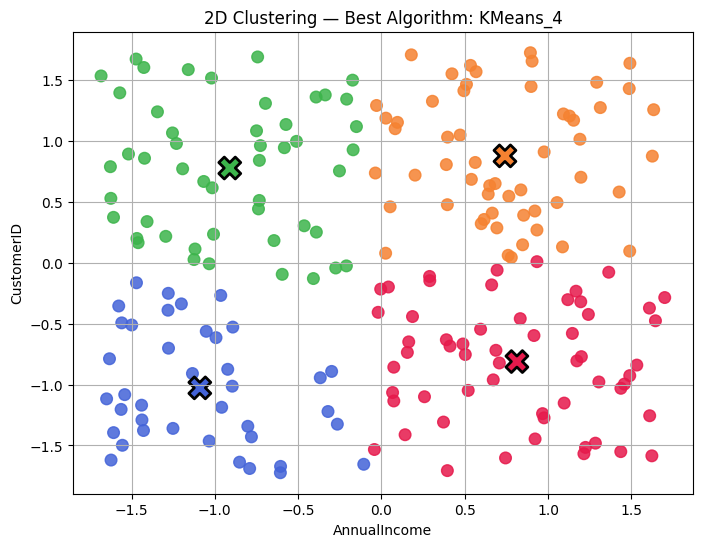

In [ ]:
fixed_colors = [
    "#e6194b", "#3cb44b", "#4363d8", "#f58231",
    "#911eb4", "#46f0f0", "#f032e6", "#bcf60c"
]

clusters = sorted(set(final_labels))
color_map = {c: fixed_colors[i % len(fixed_colors)] for i, c in enumerate(clusters)}
point_colors = [color_map[c] for c in final_labels]

plt.figure(figsize=(8, 6))
plt.scatter(X2s[:, 0], X2s[:, 1], c=point_colors, s=70, alpha=0.85)

# Plot centers if available
if final_centers is not None:
    center_colors = [color_map[i] for i in range(len(final_centers))]
    plt.scatter(
        final_centers[:, 0], final_centers[:, 1],
        c=center_colors, s=250, marker='X',
        edgecolor='black', linewidth=2
    )

plt.xlabel(best_two[0])
plt.ylabel(best_two[1])
plt.title(f"2D Clustering — Best Algorithm: {best_key}")
plt.grid(True)
plt.show()

In [ ]:
if len(best_three) >= 3:
    df_vis = pd.DataFrame(X3s, columns=best_three)
    df_vis["Cluster"] = final_labels.astype(str)
    df_vis["Color"] = [color_map[c] for c in final_labels]

    fig = px.scatter_3d(
        df_vis,
        x=best_three[0], y=best_three[1], z=best_three[2],
        color="Cluster",
        color_discrete_map={str(c): color_map[c] for c in clusters},
        title="3D Clustering (Same Colors as 2D)"
    )
    fig.update_traces(marker=dict(size=4))
    fig.show()
else:
    print("Not enough numeric columns for 3D visualization.")